# Local IBD from linked markers

Two people carry the same allele at one marker. Did they inherit it from the same ancestor?

## Start from first principles

- **Identity by state (IBS)** is an observed allele match.
- **Identity by descent (IBD)** means that the matching alleles descend from the same ancestral copy.
- One IBS match is common by chance. It cannot establish IBD.
- An IBD segment extends across linked markers until recombination breaks it.

The local IBD state is hidden. Dense markers provide a noisy matching pattern around it. A hidden Markov model (HMM) uses the persistence of an inherited segment to combine that evidence.

## 1. A small chromosome

Let $K_m=1$ mean that a pair shares at least one allele IBD at marker $m$, and let $K_m=0$ mean no local IBD. Full models may distinguish zero, one, or two shared copies. The binary state keeps the first example small.

Let $M_m=1$ record an observed allele match. The example uses

$$
P(M_m=1\mid K_m=1)=0.95,
\qquad
P(M_m=1\mid K_m=0)=0.55.
$$

A match is likely inside an IBD segment, but it is also possible outside one. Adjacent hidden states usually remain the same,

$$
P(K_m\neq K_{m-1})=0.04.
$$

These probabilities are illustrative. The fixed IBD segment makes the known answer visible.

In [1]:
set.seed(8149)

n_markers <- 80
marker <- seq_len(n_markers)

true_ibd <- integer(n_markers)
true_ibd[28:58] <- 1

match_probability <- c(`no IBD` = 0.55, IBD = 0.95)
observed_match <- rbinom(
  n_markers,
  size = 1,
  prob = match_probability[true_ibd + 1]
)

data.frame(
  marker = marker[24:34],
  observed_match = observed_match[24:34],
  truth_for_checking = true_ibd[24:34]
)

marker,observed_match,truth_for_checking
<int>,<int>,<dbl>
24,0,0
25,1,0
26,1,0
27,1,0
28,1,1
29,0,1
30,1,1
31,1,1
32,1,1


## 2. Infer the hidden segment

The transition matrix says that local ancestry usually persists from one marker to the next. The emission probabilities say how much an observed match supports each hidden state.

The forward and backward recursions sum over every possible state path. Their product gives $P(K_m=1\mid M_1,\ldots,M_M)$ at each marker.

In [2]:
state_names <- c("no IBD", "IBD")
initial_probability <- c(`no IBD` = 0.75, IBD = 0.25)

transition <- matrix(
  c(0.96, 0.04,
    0.04, 0.96),
  nrow = 2,
  byrow = TRUE,
  dimnames = list(from = state_names, to = state_names)
)

emission <- cbind(
  `no IBD` = ifelse(observed_match == 1, 0.55, 0.45),
  IBD = ifelse(observed_match == 1, 0.95, 0.05)
)

forward_backward <- function(initial, transition, emission) {
  n <- nrow(emission)
  n_states <- ncol(emission)
  forward <- matrix(0, n, n_states)
  backward <- matrix(1, n, n_states)

  forward[1, ] <- initial * emission[1, ]
  forward[1, ] <- forward[1, ] / sum(forward[1, ])

  for (m in 2:n) {
    forward[m, ] <- (forward[m - 1, ] %*% transition) * emission[m, ]
    forward[m, ] <- forward[m, ] / sum(forward[m, ])
  }

  for (m in seq.int(n - 1, 1)) {
    backward[m, ] <- transition %*% (emission[m + 1, ] * backward[m + 1, ])
    backward[m, ] <- backward[m, ] / sum(backward[m, ])
  }

  posterior <- forward * backward
  posterior / rowSums(posterior)
}

posterior <- forward_backward(initial_probability, transition, emission)
colnames(posterior) <- state_names

single_marker_posterior <-
  initial_probability["IBD"] * emission[, "IBD"] /
  rowSums(sweep(emission, 2, initial_probability, `*`))

stopifnot(all(abs(rowSums(transition) - 1) < 1e-12))
stopifnot(all(abs(rowSums(posterior) - 1) < 1e-12))
stopifnot(all(posterior >= 0), all(posterior <= 1))

region,observed_match_rate,mean_posterior_IBD
<chr>,<dbl>,<dbl>
outside the true segment,0.5714286,0.09587706
inside the true segment,0.9354839,0.84783334


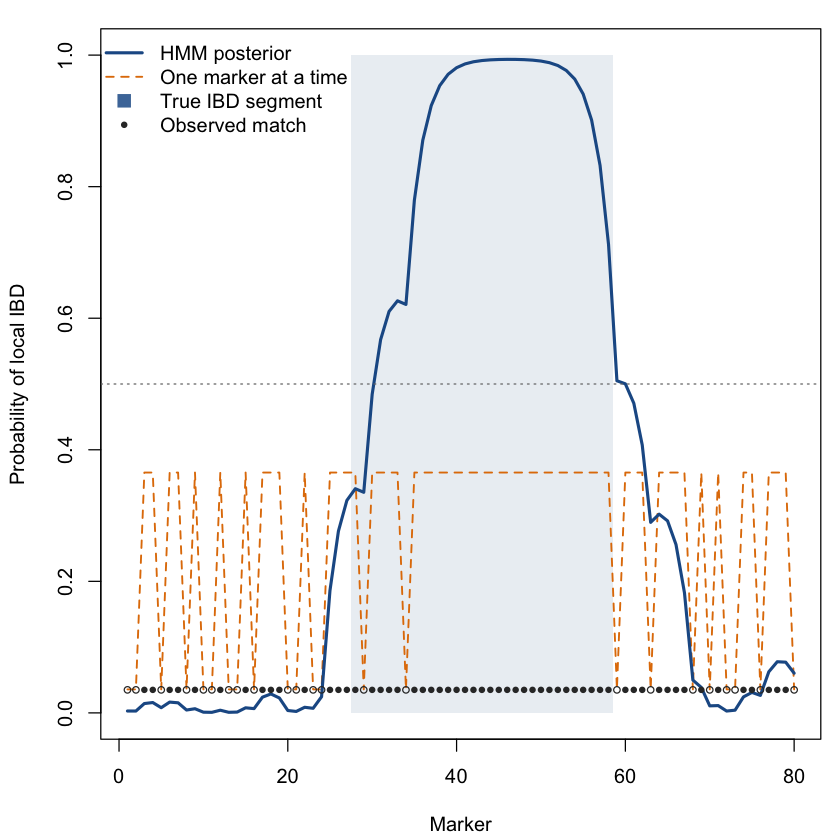

In [3]:
old_par <- par(mar = c(4.2, 4.2, 1.2, 0.8))

plot(
  marker,
  posterior[, "IBD"],
  type = "n",
  ylim = c(0, 1),
  xlab = "Marker",
  ylab = "Probability of local IBD"
)
rect(27.5, 0, 58.5, 1, col = adjustcolor("#4C78A8", 0.12), border = NA)
lines(marker, single_marker_posterior, lty = 2, lwd = 1.5, col = "#E17C05")
lines(marker, posterior[, "IBD"], lwd = 2.5, col = "#1F5A94")
points(
  marker,
  rep(0.035, n_markers),
  pch = ifelse(observed_match == 1, 16, 1),
  cex = 0.72,
  col = "#333333"
)
abline(h = 0.5, lty = 3, col = "#777777")
legend(
  "topleft",
  legend = c("HMM posterior", "One marker at a time", "True IBD segment", "Observed match"),
  col = c("#1F5A94", "#E17C05", "#4C78A8", "#333333"),
  lty = c(1, 2, NA, NA),
  lwd = c(2.5, 1.5, NA, NA),
  pch = c(NA, NA, 15, 16),
  pt.cex = c(NA, NA, 1.5, 0.72),
  bty = "n"
)

par(old_par)

data.frame(
  region = c("outside the true segment", "inside the true segment"),
  observed_match_rate = c(
    mean(observed_match[true_ibd == 0]),
    mean(observed_match[true_ibd == 1])
  ),
  mean_posterior_IBD = c(
    mean(posterior[true_ibd == 0, "IBD"]),
    mean(posterior[true_ibd == 1, "IBD"])
  )
)

## Why linked markers help

The dashed line treats every marker separately. It can only react to the match at that marker. The solid line also uses neighboring markers. A run of matches supports one persistent ancestral segment, while an isolated match remains weak evidence.

This is the same HMM logic used in genotype imputation. A hidden state persists along a chromosome, recombination can change it, and observed alleles provide imperfect evidence about it.

## What to remember

- **Concept and intuition.** IBS is an observed match. IBD is shared ancestry. One match is weak evidence, while a linked run can mark an inherited segment.
- **Insight behind the approach.** Put local IBD in a hidden state. Let recombination govern transitions and genotype agreement govern emissions.
- **Worked example.** The HMM recovered one fixed IBD segment and retained uncertainty near its boundaries.

## Sources

- Pritchard, *An Owner's Guide to the Human Genome*, review Chapter 2.3 and the linkage material in Chapters 4.1--4.2. [Book page](https://web.stanford.edu/group/pritchardlab/HGbook.html)
- Gorroochurn, *Notes on Population Genetics*, Section 7.2.
- The simulation is an original course example. It uses 80 markers, a fixed IBD segment at markers 28--58, switch probability 0.04, match probabilities 0.55 and 0.95, and seed 8149.